## Introduction
Banking crises can have severe impacts on economic stability, financial markets, and global trade. Identifying early warning 

signals of such crises is important for policymakers and financial institutions. In this project, machine learning techniques are

used to analyze economic and financial indicators in order to predict the occurrence of banking crises. The models aim to identify

factors that contribute to financial instability.

## Problem Statement
Banking crises are complex events influenced by multiple economic and financial factors. Detecting these crises early

is challenging due to the large number of variables involved. The problem addressed in this project is to build a machine 

learning model that can predict the likelihood of a banking crisis using financial data.

## Objective
**The main objectives of this project are:**

* To analyze the relationship between economic indicators and banking crises.

* To apply machine learning models to predict the occurrence of banking crises.

* To evaluate and compare the performance of different classification models.

* To identify the most important variables influencing banking crisis prediction.

## Dataset Description
The dataset used in this project contains historical economic and financial indicators related to banking crises.

It includes variables such as GDP growth, credit to GDP ratio, stock market capitalization, trade values,

recession indicators, and crisis-related measures. The target variable BANK indicates whether a banking crisis 

occurred (1) or not (0). The dataset consists of 39,588 observations and 44 variables, providing a comprehensive view 

of macroeconomic conditions that may contribute to financial instability.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [158]:
df = pd.read_csv('finaldataset_1.csv')
df.head()

,exporter,year,product,tradevalue,tradeshare,expgrowth,expgrowthTRIM,BANK,BANK_W3,TWIN,...,CCC,RZyoung,rznoncrisis,caplab,rd,homogeneity,n,herf,intout,contcrisis
0,ARG,1980.0,3111,1.095743e+06,NaN,NaN,NaN,0.0,0,0.0,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
1,ARG,1981.0,3111,1.053351e+06,NaN,-0.039456,-0.039456,0.0,0,0.0,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
2,ARG,1982.0,3111,8.524701e+05,NaN,-0.211594,-0.211594,0.0,0,0.0,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
3,ARG,1983.0,3111,6.446367e+05,0.252277,-0.279451,-0.279451,0.0,0,0.0,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
4,ARG,1984.0,3111,4.481481e+05,0.236616,-0.363563,-0.363563,0.0,0,0.0,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0


## Basic Data Understanding

In [87]:
df.shape

(39588, 44)

In [88]:
print('Number of rows:' , df.shape[0])
print('Number of columns:', df.shape[1])

Number of rows: 39588
Number of columns: 44


In [89]:
df.size

1741872

In [90]:
df.info

<bound method DataFrame.info of       exporter    year  product    tradevalue  tradeshare  expgrowth  \
0          ARG  1980.0     3111  1.095743e+06         NaN        NaN   
1          ARG  1981.0     3111  1.053351e+06         NaN  -0.039456   
2          ARG  1982.0     3111  8.524701e+05         NaN  -0.211594   
3          ARG  1983.0     3111  6.446367e+05    0.252277  -0.279451   
4          ARG  1984.0     3111  4.481481e+05    0.236616  -0.363563   
...        ...     ...      ...           ...         ...        ...   
39583      USA  2002.0     3909  7.635533e+06    0.014684  -0.027248   
39584      USA  2003.0     3909  8.039191e+06    0.012614   0.051517   
39585      USA  2004.0     3909  8.715190e+06    0.011960   0.080739   
39586      USA  2005.0     3909  9.842128e+06    0.012334   0.121604   
39587      USA  2006.0     3909  1.049364e+07    0.012530   0.064098   

       expgrowthTRIM  BANK  BANK_W3  TWIN  ...       CCC  RZyoung  \
0                NaN   0.0        

In [91]:
df.columns

Index(['exporter', 'year', 'product', 'tradevalue', 'tradeshare', 'expgrowth',
       'expgrowthTRIM', 'BANK', 'BANK_W3', 'TWIN', 'RZ', 'FL', 'TANG',
       'ofagdp', 'pcrdbofgdp', 'stmktcap', 'RecessionAbroad', 'GDPgrAbroad',
       'durables', 'loss', 'loss2', 'GDPcap', 'developed', 'developing',
       'blanguar', 'liqsup', 'forba', 'forbb', 'recaps', 'debtrelief',
       'policytot', 'recession', 'GDPgr', 'INVSA', 'CCC', 'RZyoung',
       'rznoncrisis', 'caplab', 'rd', 'homogeneity', 'n', 'herf', 'intout',
       'contcrisis'],
      dtype='object')

In [92]:
df.describe()

,year,product,tradevalue,tradeshare,expgrowth,expgrowthTRIM,BANK,BANK_W3,TWIN,RZ,...,CCC,RZyoung,rznoncrisis,caplab,rd,homogeneity,n,herf,intout,contcrisis
count,39588.000000,39588.000000,3.958800e+04,3.547200e+04,37596.000000,33862.000000,39480.000000,39588.000000,37843.000000,38111.000000,...,38258.000000,37081.000000,38111.000000,38111.000000,38111.000000,30351.000000,37268.000000,37268.000000,37268.000000,39588.000000
mean,1993.528241,3508.390093,8.400046e+05,1.381927e-02,0.104838,0.098511,0.044200,0.128397,0.002854,0.308841,...,1.044697,0.660228,0.128036,29.586375,0.027806,0.229943,1.147987,0.805050,1.026452,0.018970
std,7.623218,287.231154,4.286242e+06,4.178049e-02,0.786542,0.338992,0.205541,0.334536,0.053346,0.326493,...,0.406432,0.602414,0.278176,30.663965,0.068116,0.420803,0.307521,0.556441,0.155052,0.136422
min,1980.000000,3111.000000,1.000000e+00,4.280925e-09,-8.565605,-1.527041,0.000000,0.000000,0.000000,-0.450000,...,0.189755,-1.530000,-0.250000,7.120000,0.000000,0.000000,0.403000,0.352000,0.611000,0.000000
25%,1987.000000,3215.000000,2.180100e+03,5.865885e-04,-0.087494,-0.064466,0.000000,0.000000,0.000000,0.140000,...,0.818567,0.570000,-0.010000,18.049999,0.010000,0.000000,0.879000,0.497000,0.931000,0.000000
50%,1994.000000,3523.000000,2.540083e+04,2.581258e-03,0.084501,0.084501,0.000000,0.000000,0.000000,0.240000,...,0.977674,0.660000,0.050000,21.780001,0.010000,0.000000,1.179000,0.560000,0.982000,0.000000
75%,2000.000000,3823.000000,2.068987e+05,1.003533e-02,0.273260,0.246487,0.000000,0.000000,0.000000,0.450000,...,1.345260,0.870000,0.250000,31.080000,0.020000,0.000000,1.333000,0.983000,1.119000,0.000000
max,2006.000000,3909.000000,1.360298e+08,9.521001e-01,8.630626,1.523365,1.000000,1.000000,1.000000,1.490000,...,1.990121,2.060000,1.550000,244.649994,0.580000,1.000000,1.729000,4.160000,1.503000,1.000000


**Datatypes of variables**

In [93]:
df.dtypes

exporter            object
year               float64
product              int64
tradevalue         float64
tradeshare         float64
expgrowth          float64
expgrowthTRIM      float64
BANK               float64
BANK_W3              int64
TWIN               float64
RZ                 float64
FL                 float64
TANG               float64
ofagdp             float64
pcrdbofgdp         float64
stmktcap           float64
RecessionAbroad    float64
GDPgrAbroad        float64
durables             int64
loss               float64
loss2              float64
GDPcap             float64
developed            int64
developing           int64
blanguar           float64
liqsup             float64
forba              float64
forbb              float64
recaps             float64
debtrelief         float64
policytot          float64
recession            int64
GDPgr              float64
INVSA              float64
CCC                float64
RZyoung            float64
rznoncrisis        float64
c

## Removing unnecessary columns

In [94]:
df.drop(columns=['exporter','year','product','developed','developing'], axis = 1 , inplace = True)

## Missing values

In [95]:
df.isnull().sum()

tradevalue             0
tradeshare          4116
expgrowth           1992
expgrowthTRIM       5726
BANK                 108
BANK_W3                0
TWIN                1745
RZ                  1477
FL                  1477
TANG                1477
ofagdp             23731
pcrdbofgdp          1744
stmktcap            8447
RecessionAbroad        0
GDPgrAbroad            0
durables               0
loss                   0
loss2                  0
GDPcap                 0
blanguar           14853
liqsup             14853
forba              14853
forbb              14853
recaps             14853
debtrelief         14853
policytot          14853
recession              0
GDPgr                  0
INVSA               1330
CCC                 1330
RZyoung             2507
rznoncrisis         1477
caplab              1477
rd                  1477
homogeneity         9237
n                   2320
herf                2320
intout              2320
contcrisis             0
dtype: int64

In [96]:
df.skew()

tradevalue         12.653652
tradeshare          9.222734
expgrowth           0.346164
expgrowthTRIM       0.226220
BANK                4.435356
BANK_W3             2.221711
TWIN               18.639435
RZ                  1.158262
FL                  0.197528
TANG                0.452905
ofagdp              1.495433
pcrdbofgdp          0.930550
stmktcap            2.039393
RecessionAbroad     1.702314
GDPgrAbroad         0.620433
durables            0.173741
loss                6.984261
loss2              -0.217836
GDPcap              1.026027
blanguar            6.014006
liqsup              6.480784
forba              12.555567
forbb               5.327870
recaps              8.663168
debtrelief         12.514230
policytot           5.961966
recession           1.344347
GDPgr              -0.725362
INVSA               0.726261
CCC                 0.071536
RZyoung            -1.484910
rznoncrisis         2.970119
caplab              5.043474
rd                  7.164634
homogeneity   

## Treating Null values

In [97]:
df['tradeshare'] = df['tradeshare'].fillna(df['tradeshare'].median())
df['expgrowth'] = df['expgrowth'].fillna(df['expgrowth'].mean())
df['expgrowthTRIM'] = df['expgrowthTRIM'].fillna(df['expgrowthTRIM'].mean())
df['BANK'] = df['BANK'].fillna(df['BANK'].mean())
df['TWIN'] = df['TWIN'].fillna(df['TWIN'].median())
df['RZ'] = df['RZ'].fillna(df['RZ'].mean())
df['FL'] = df['FL'].fillna(df['FL'].mean())
df['TANG'] = df['TANG'].fillna(df['TANG'].mean())
df['ofagdp'] = df['ofagdp'].fillna(df['ofagdp'].mean())
df['pcrdbofgdp'] = df['pcrdbofgdp'].fillna(df['pcrdbofgdp'].mean())
df['stmktcap'] = df['stmktcap'].fillna(df['stmktcap'].mean())
df['blanguar'] = df['blanguar'].fillna(df['blanguar'].median())
df['liqsup'] = df['liqsup'].fillna(df['liqsup'].median())
df['forba'] = df['forba'].fillna(df['forba'].median())
df['forbb'] = df['forbb'].fillna(df['forbb'].mean())
df['recaps'] = df['recaps'].fillna(df['recaps'].median())
df['debtrelief'] = df['debtrelief'].fillna(df['debtrelief'].median())
df['policytot'] = df['policytot'].fillna(df['policytot'].mean())
df['INVSA'] = df['INVSA'].fillna(df['INVSA'].mean())
df['CCC'] = df['CCC'].fillna(df['CCC'].mean())
df['RZyoung'] = df['RZyoung'].fillna(df['RZyoung'].median())
df['rznoncrisis'] = df['rznoncrisis'].fillna(df['rznoncrisis'].mean())
df['caplab'] = df['caplab'].fillna(df['caplab'].median())
df['rd'] = df['rd'].fillna(df['rd'].median())
df['homogeneity'] = df['homogeneity'].fillna(df['homogeneity'].mean())
df['n'] = df['n'].fillna(df['n'].median())
df['herf'] = df['herf'].fillna(df['herf'].mean())
df['intout'] = df['intout'].fillna(df['intout'].mean())

**Inference:** Missing values were handled using statistical imputation. Variables with low skewness were imputed using the mean, while variables with high skewness were imputed using the median to reduce the influence of outliers.

## Checking duplicates

In [98]:
df[df.duplicated()]

,tradevalue,tradeshare,expgrowth,expgrowthTRIM,BANK,BANK_W3,TWIN,RZ,FL,TANG,...,CCC,RZyoung,rznoncrisis,caplab,rd,homogeneity,n,herf,intout,contcrisis


* No duplicates columns

## Checking anomalies

In [99]:
for i in df.columns:
    print(i)
    print(df[i].unique())
    print('__________________')

tradevalue
[ 1095742.59904718  1053351.37174797   852470.13552952 ...
  8715190.20430589  9842127.8984046  10493639.96584988]
__________________
tradeshare
[0.00258126 0.2522769  0.2366164  ... 0.01196025 0.01233397 0.01253016]
__________________
expgrowth
[ 0.10483789 -0.03945637 -0.21159363 ...  0.08073902  0.12160397
  0.06409836]
__________________
expgrowthTRIM
[ 0.09851121 -0.03945637 -0.21159363 ...  0.08073902  0.12160397
  0.06409836]
__________________
BANK
[0.         0.04419959 1.        ]
__________________
BANK_W3
[0 1]
__________________
TWIN
[0. 1.]
__________________
RZ
[ 0.14        0.30884075  0.08       -0.44999999 -0.09        0.40000001
  0.03       -0.14       -0.08        0.28        0.23999999  0.15000001
  0.18000001  0.2         0.25        0.16        0.22        1.49000001
  0.04        0.33000001  0.23        1.13999999 -0.15000001  0.52999997
  0.06        0.09        0.01        0.44999999  1.05999994  0.76999998
  1.03999996  0.46000001  0.31        0.3

**Inference:** No anomalies , Continuous economic indicators were retained as float variables, while binary indicators  were stored as integer types.

## Separating numeric and categoric columns

In [100]:
num = df.select_dtypes(include = 'number').columns.tolist()
cat = df.select_dtypes(include = object).columns.tolist()

In [101]:
df[num].columns

Index(['tradevalue', 'tradeshare', 'expgrowth', 'expgrowthTRIM', 'BANK',
       'BANK_W3', 'TWIN', 'RZ', 'FL', 'TANG', 'ofagdp', 'pcrdbofgdp',
       'stmktcap', 'RecessionAbroad', 'GDPgrAbroad', 'durables', 'loss',
       'loss2', 'GDPcap', 'blanguar', 'liqsup', 'forba', 'forbb', 'recaps',
       'debtrelief', 'policytot', 'recession', 'GDPgr', 'INVSA', 'CCC',
       'RZyoung', 'rznoncrisis', 'caplab', 'rd', 'homogeneity', 'n', 'herf',
       'intout', 'contcrisis'],
      dtype='object')

In [102]:
df[cat].columns

Index([], dtype='object')

Inference: There are no columns that has object

## Outliers

In [103]:
IQR = df[num].quantile(0.75) - df[num].quantile(0.25)

In [104]:
upper_whis = df[num].quantile(0.75) + (1.5*IQR)

In [105]:
low_whis = df[num].quantile(0.25) - (1.5*IQR)

In [106]:
outliers = df[((df[num] < low_whis) | (df[num] > upper_whis)).any(axis = 1)]
outliers

,tradevalue,tradeshare,expgrowth,expgrowthTRIM,BANK,BANK_W3,TWIN,RZ,FL,TANG,...,CCC,RZyoung,rznoncrisis,caplab,rd,homogeneity,n,herf,intout,contcrisis
0,1.095743e+06,0.002581,0.104838,0.098511,0.0,0,0.0,0.14,0.112,0.37,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
1,1.053351e+06,0.002581,-0.039456,-0.039456,0.0,0,0.0,0.14,0.112,0.37,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
2,8.524701e+05,0.002581,-0.211594,-0.211594,0.0,0,0.0,0.14,0.112,0.37,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
3,6.446367e+05,0.252277,-0.279451,-0.279451,0.0,0,0.0,0.14,0.112,0.37,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
4,4.481481e+05,0.236616,-0.363563,-0.363563,0.0,0,0.0,0.14,0.112,0.37,...,0.425463,0.66,0.05,25.17,0.01,0.0,1.333,0.497,1.226,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39583,7.635533e+06,0.014684,-0.027248,-0.027248,0.0,0,0.0,0.47,0.087,0.18,...,1.405696,0.80,0.31,14.54,0.02,0.0,1.311,0.450,0.961,0
39584,8.039191e+06,0.012614,0.051517,0.051517,0.0,0,0.0,0.47,0.087,0.18,...,1.405696,0.80,0.31,14.54,0.02,0.0,1.311,0.450,0.961,0
39585,8.715190e+06,0.011960,0.080739,0.080739,0.0,0,0.0,0.47,0.087,0.18,...,1.405696,0.80,0.31,14.54,0.02,0.0,1.311,0.450,0.961,0
39586,9.842128e+06,0.012334,0.121604,0.121604,0.0,0,0.0,0.47,0.087,0.18,...,1.405696,0.80,0.31,14.54,0.02,0.0,1.311,0.450,0.961,0


## Visualization

In [107]:
df[num].shape[1]

39

In [108]:
plt.rcParams['figure.figsize'] = [15,40]

**Distribution of numeric variables**

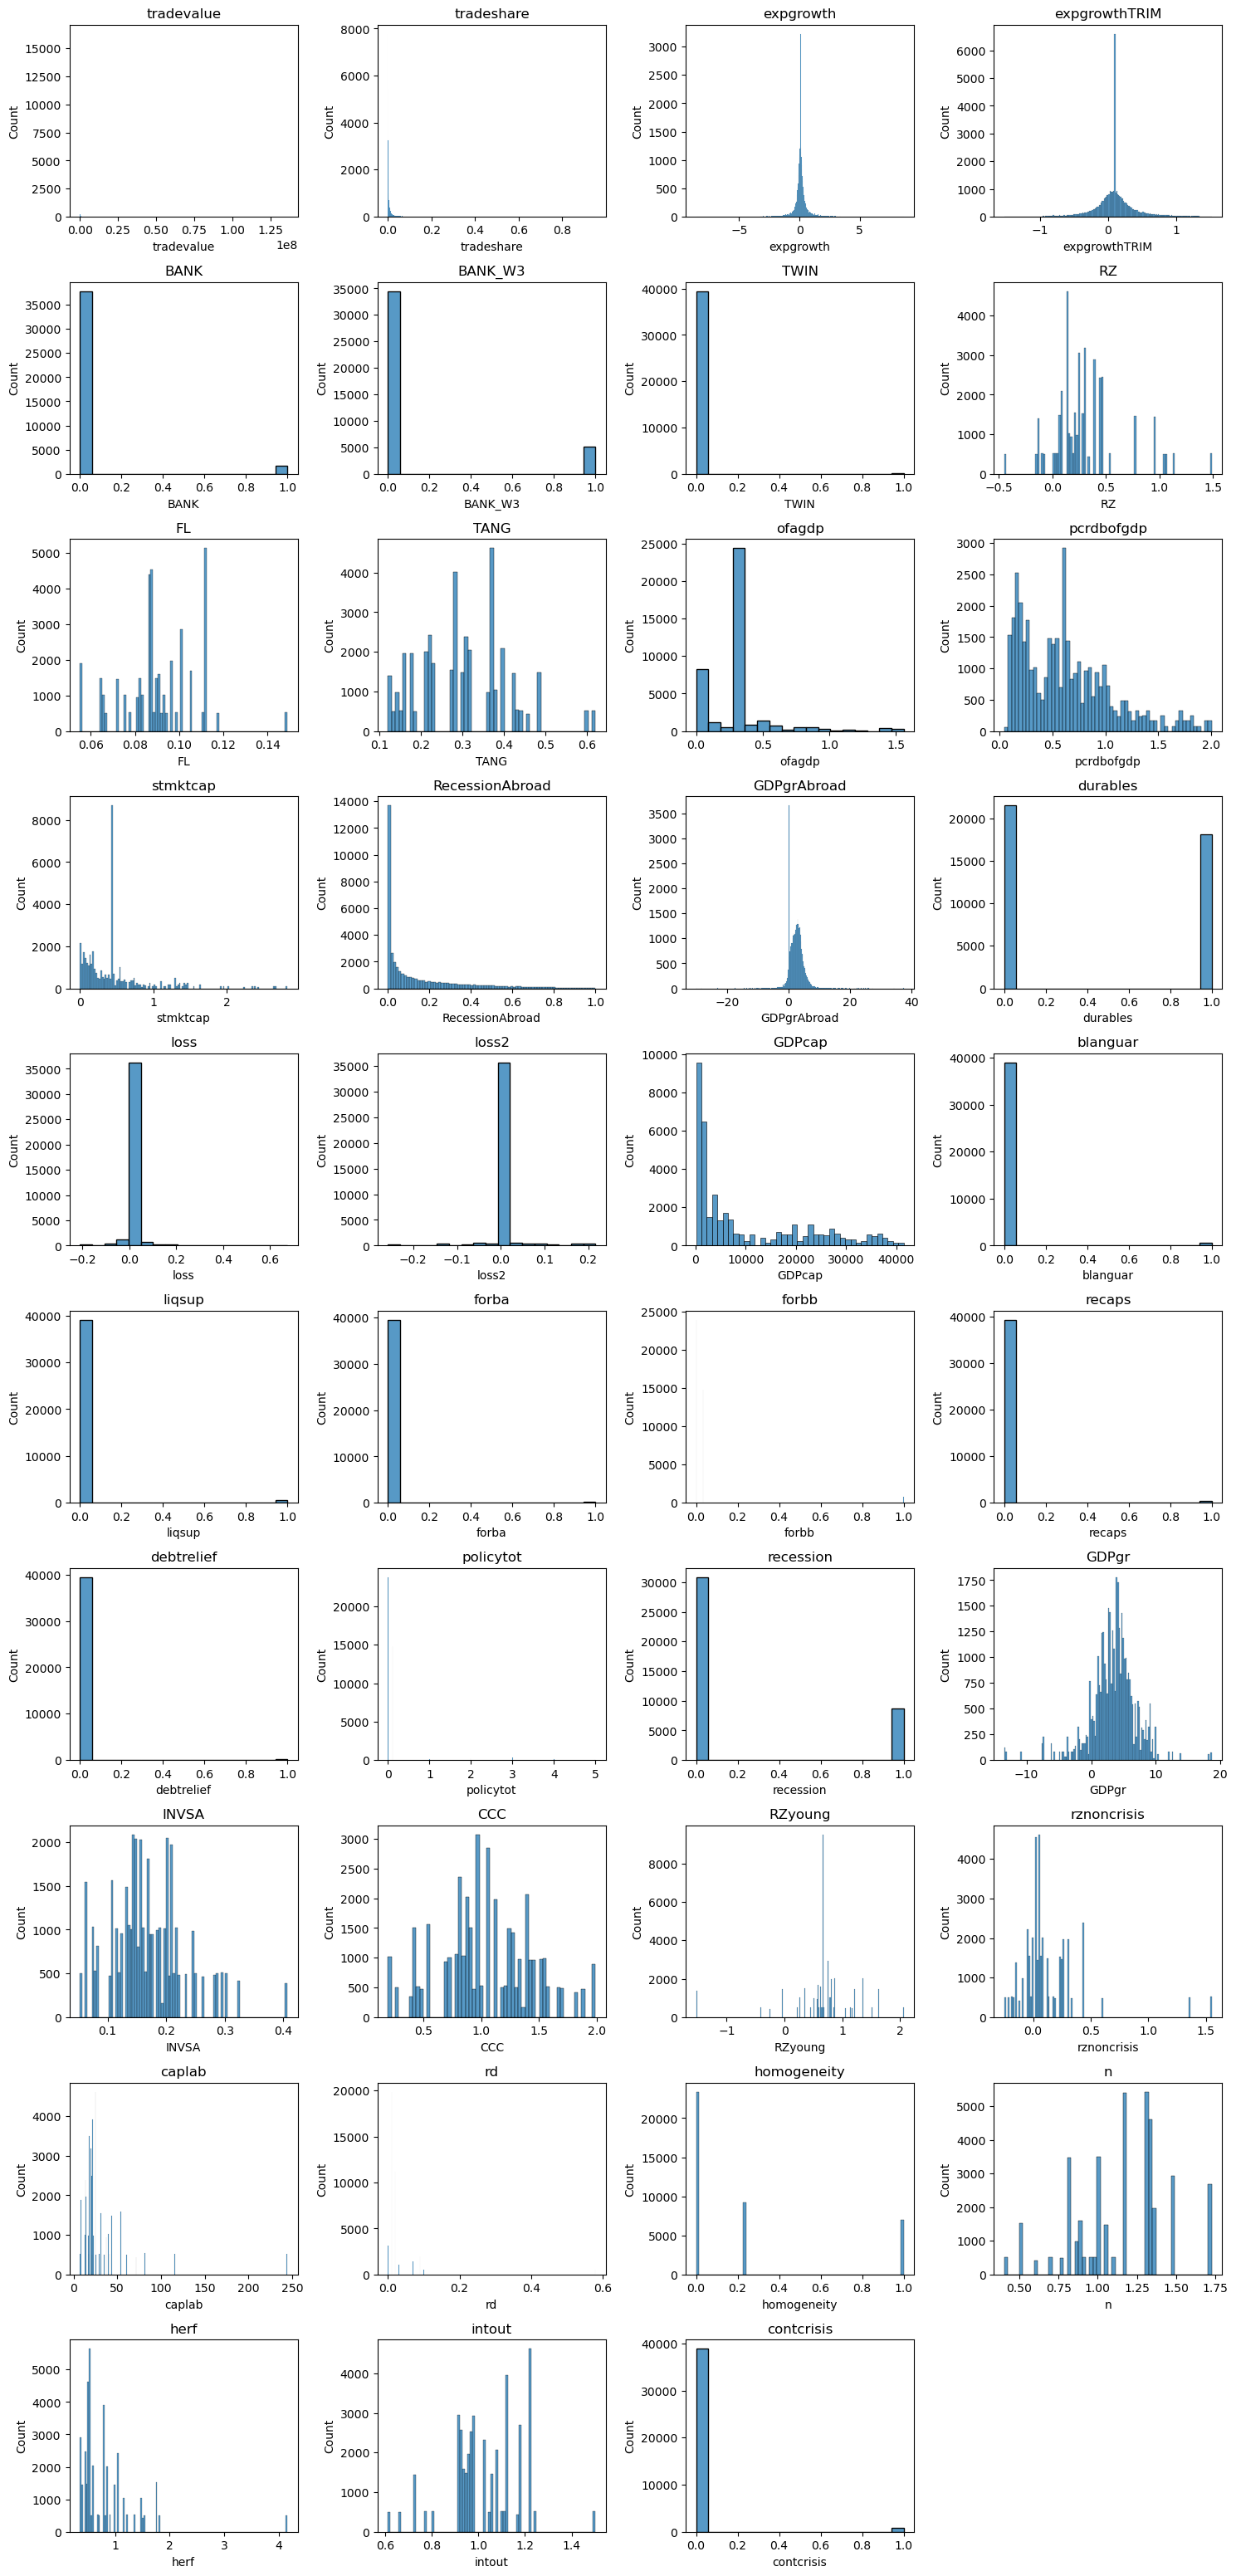

In [109]:
p = 1
for i in num:
    plt.subplot(13,4,p)
    sns.histplot(df[i])
    plt.title(f'{i}')
    p+=1
plt.tight_layout()
plt.show()

**Inference:** The histograms indicate that most variables are right-skewed with values concentrated at lower ranges and

a few extreme observations. Crisis-related variables are binary and highly imbalanced, while indicators such as GDP growth and export growth 

show more continuous distributions centered around moderate values.

**Export growth Distribution**

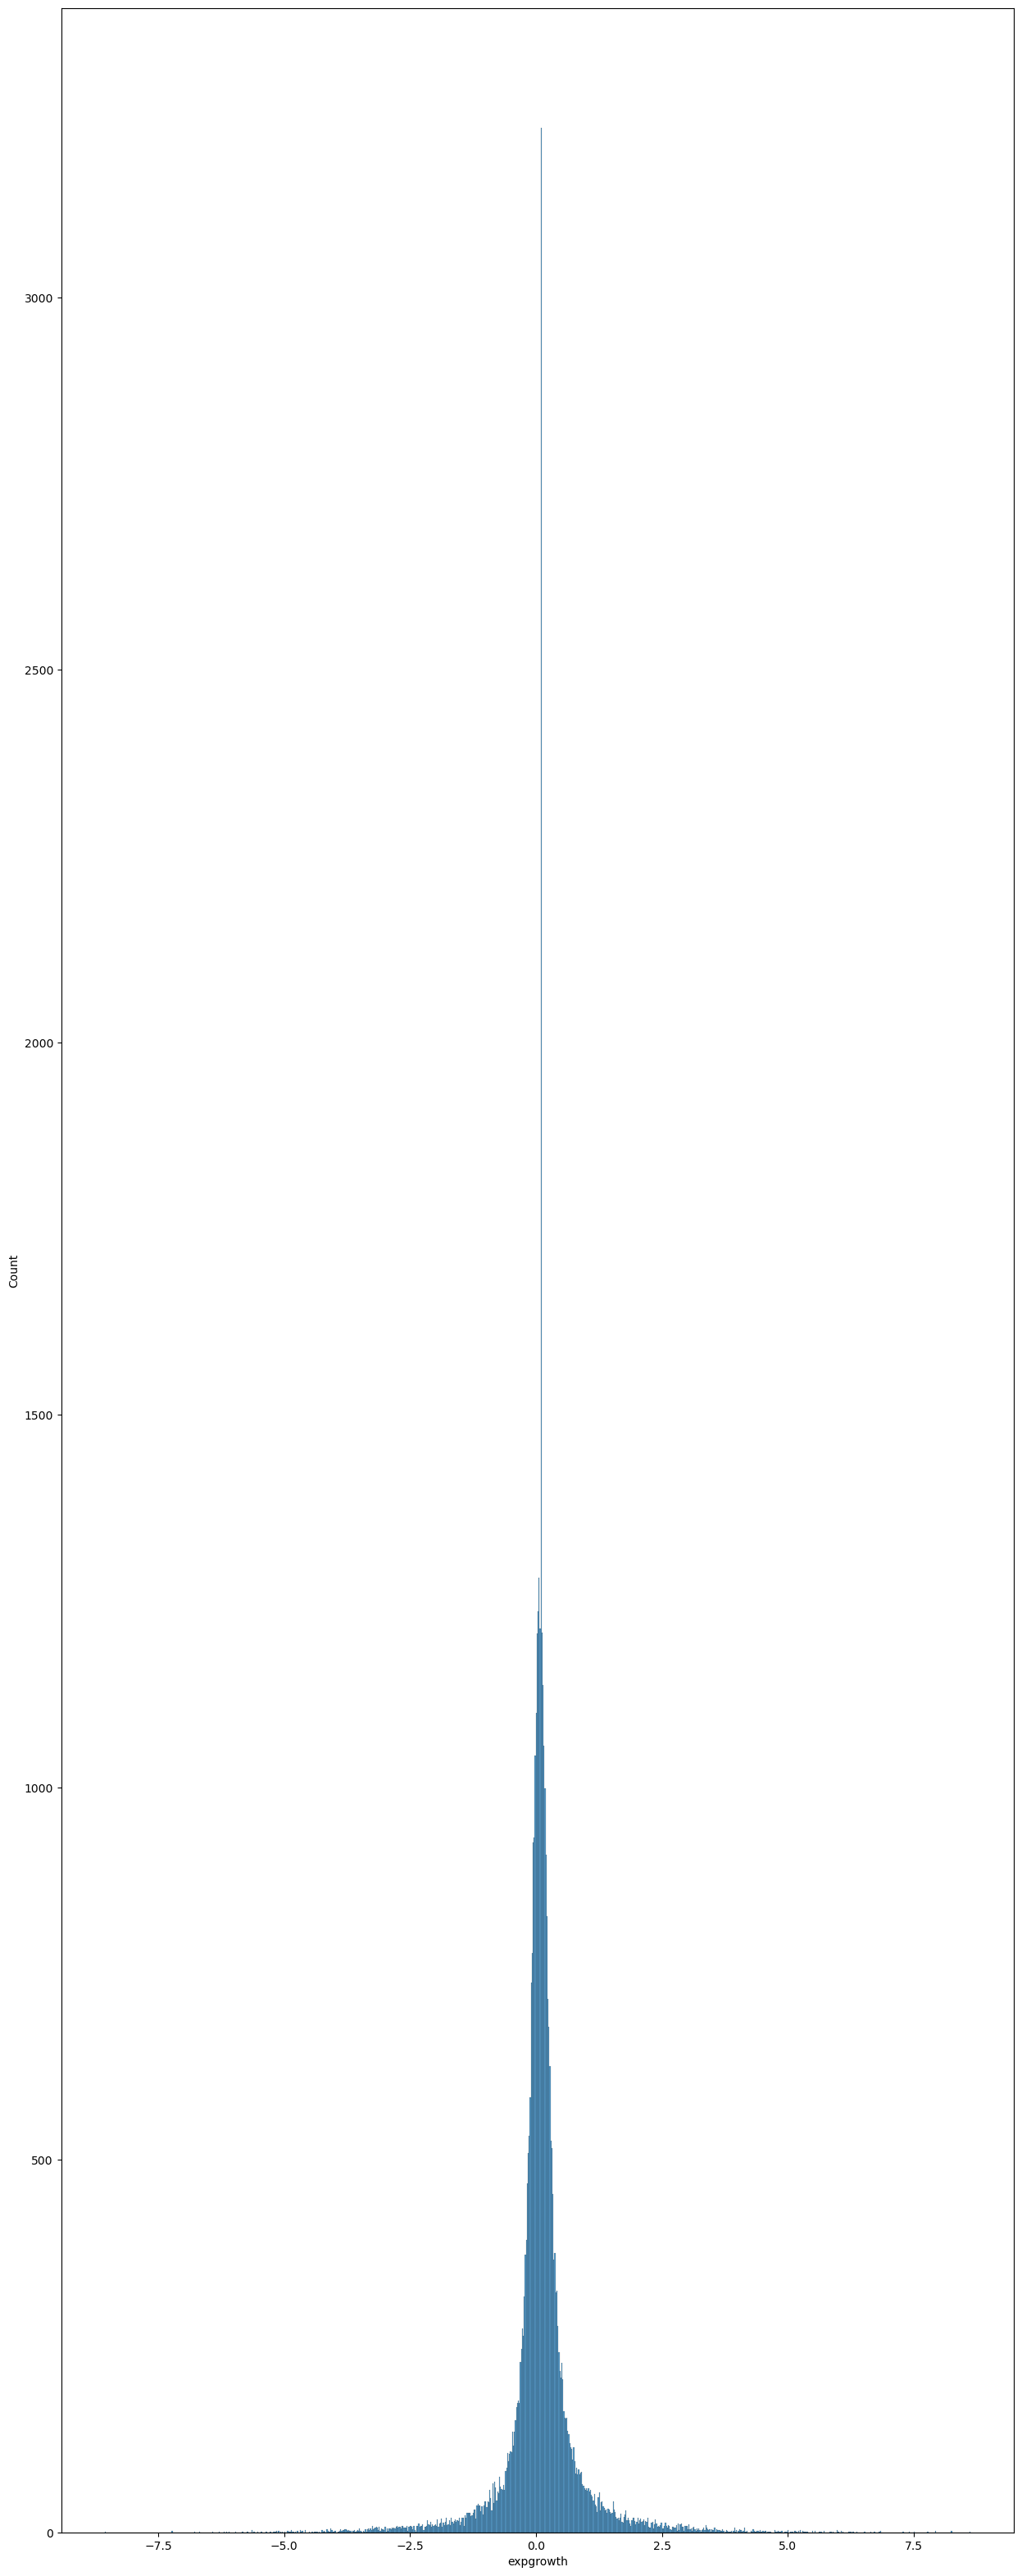

In [110]:
sns.histplot(df['expgrowth'])
plt.show()

**Inference:** Export growth is highly concentrated around zero, indicating that most observations

show small changes in exports, while extreme positive and negative growth values occur less frequently.

**Banking crisis count**

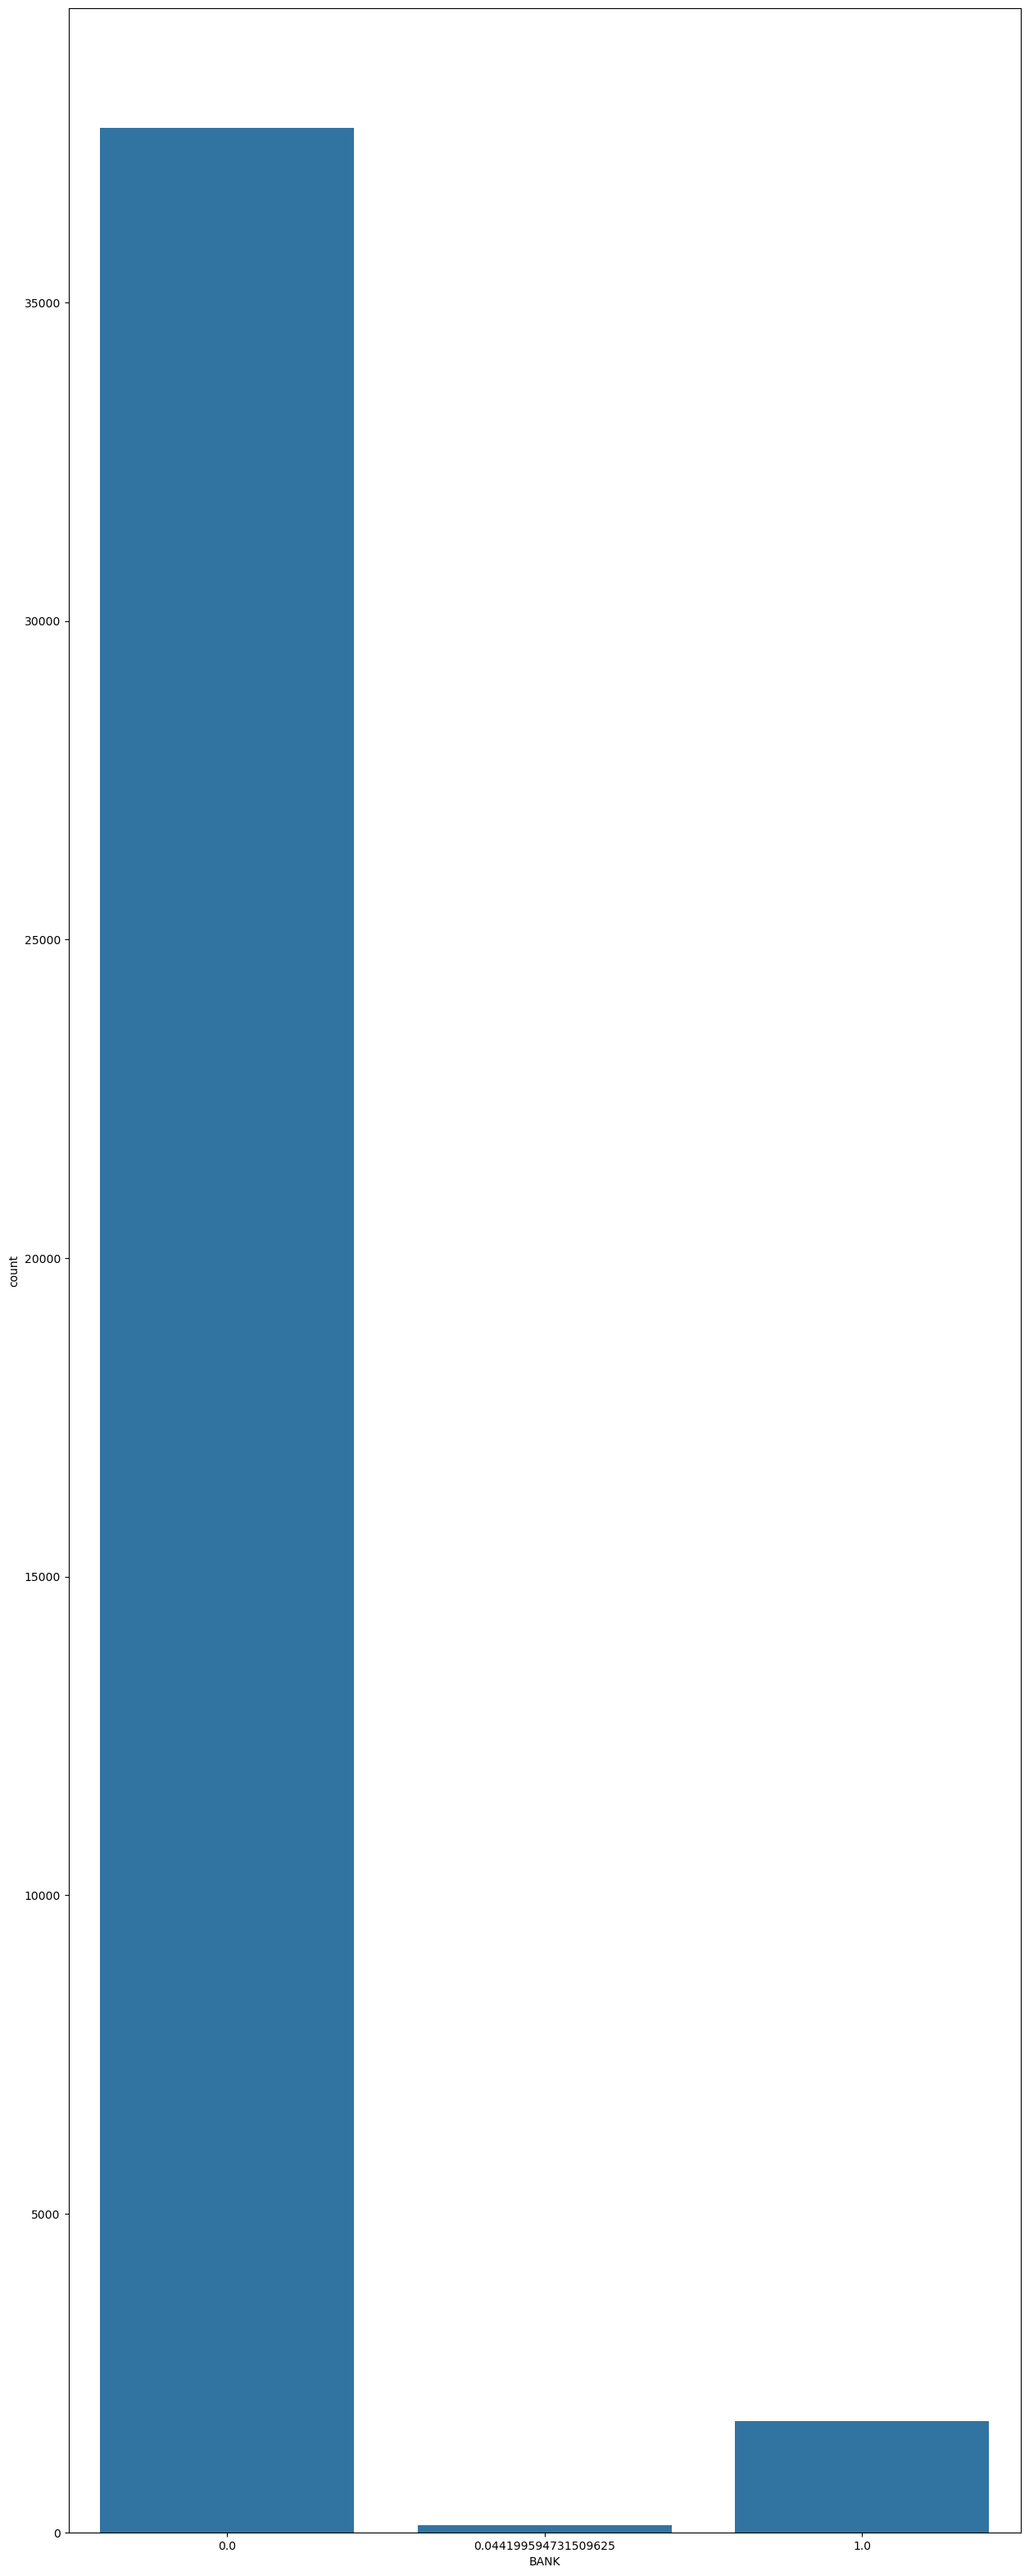

In [111]:
sns.countplot(x='BANK', data=df)
plt.show()

**Inference**: The dataset is highly imbalanced, with most observations representing non-banking crisis

periods and relatively few observations representing banking crisis events.

**Export Growth and banking crisis**

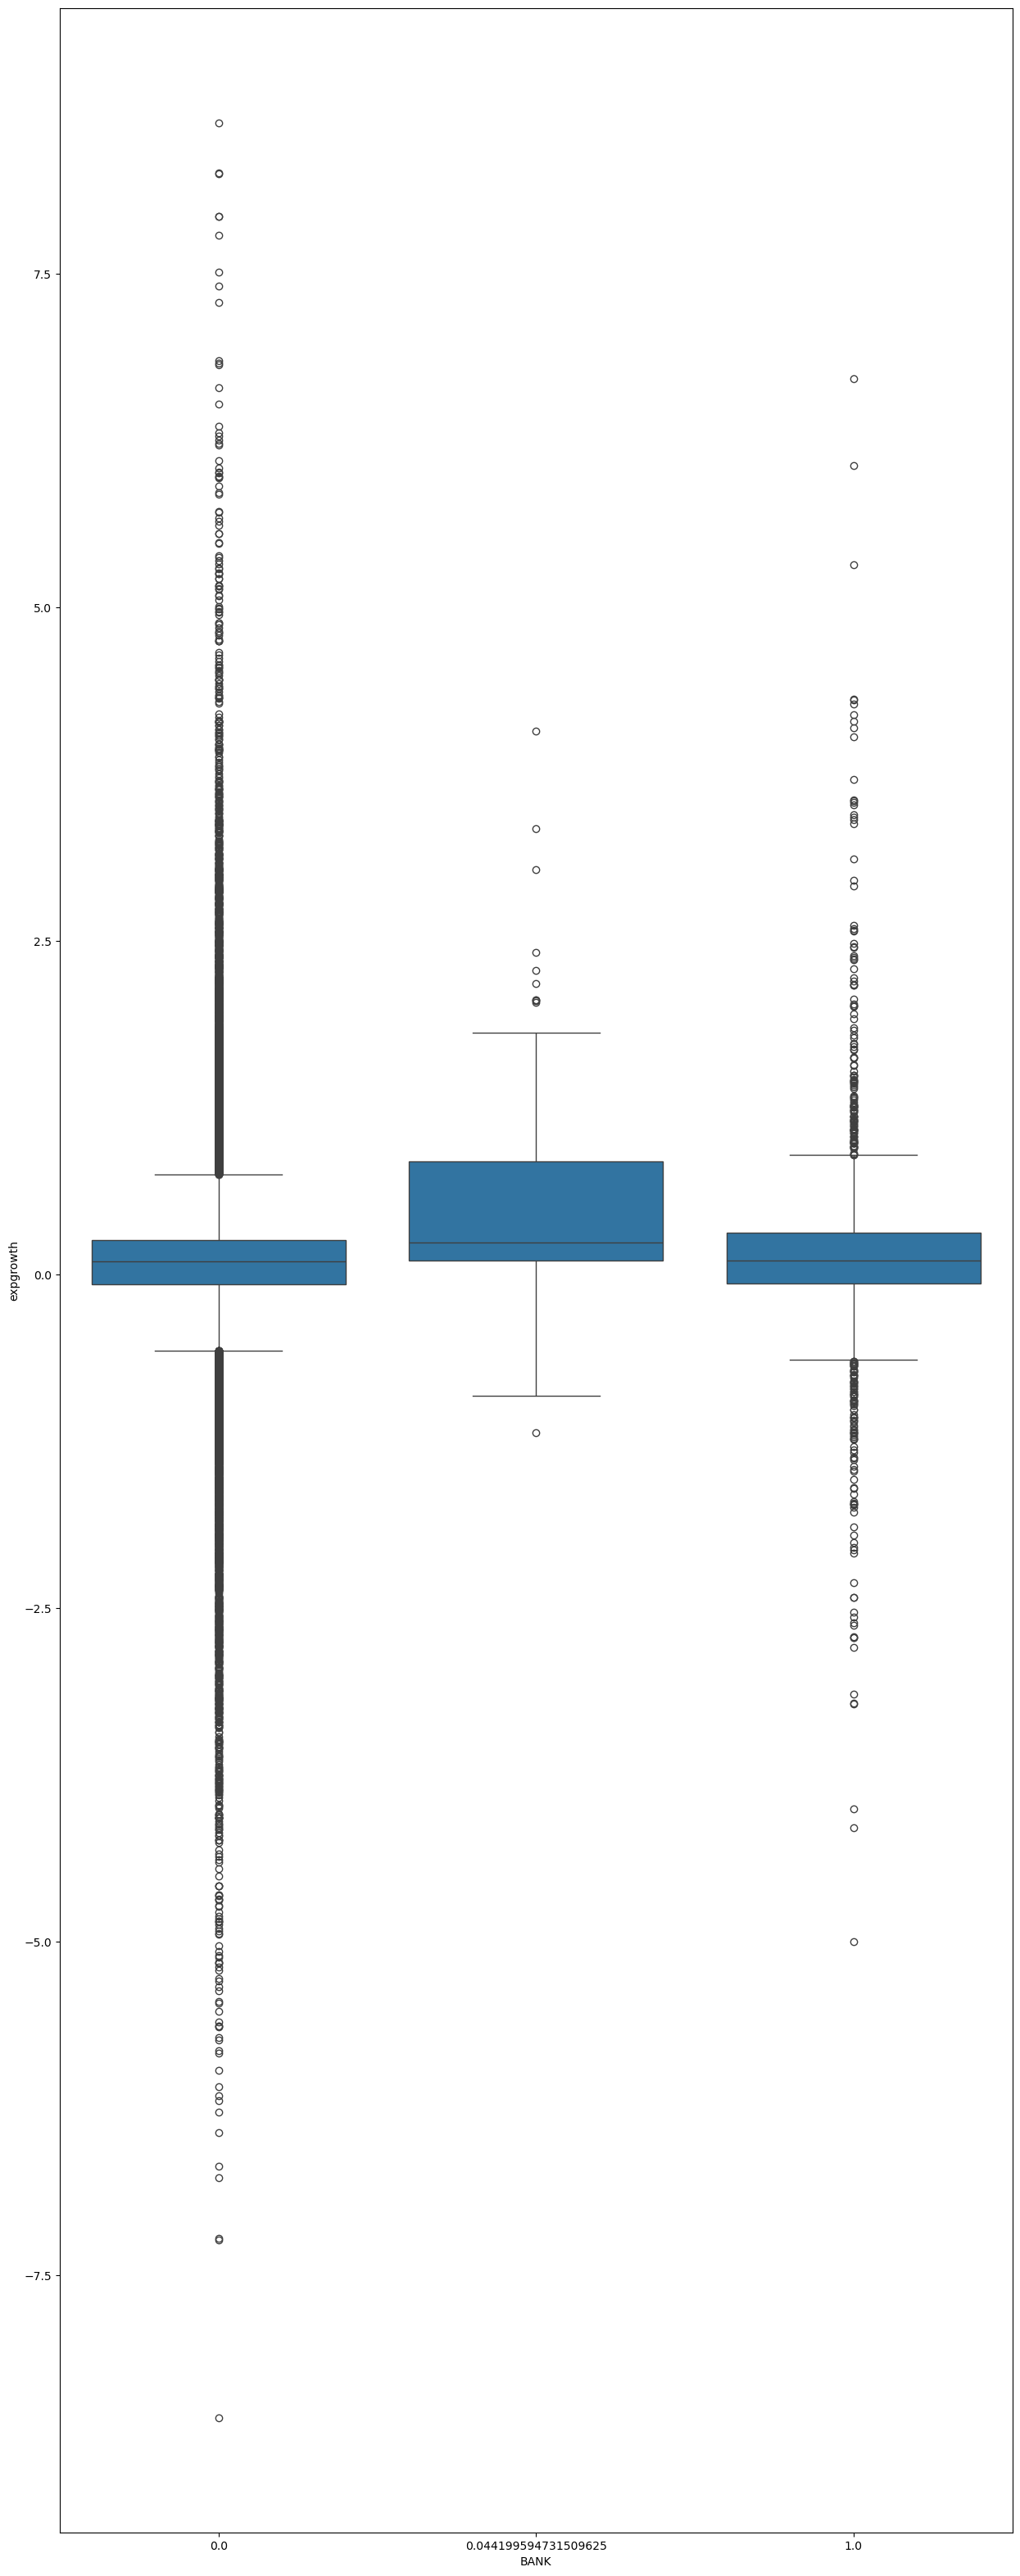

In [112]:
sns.boxplot(x='BANK', y='expgrowth', data=df)
plt.show()

**Inference**: Export growth shows high variability and many outliers in both crisis and non-crisis periods.

The strong overlap between the distributions suggests that banking crises alone may not

significantly determine export growth patterns.

## Correlation analysis

In [113]:
plt.rcParams['figure.figsize'] = [30,20]

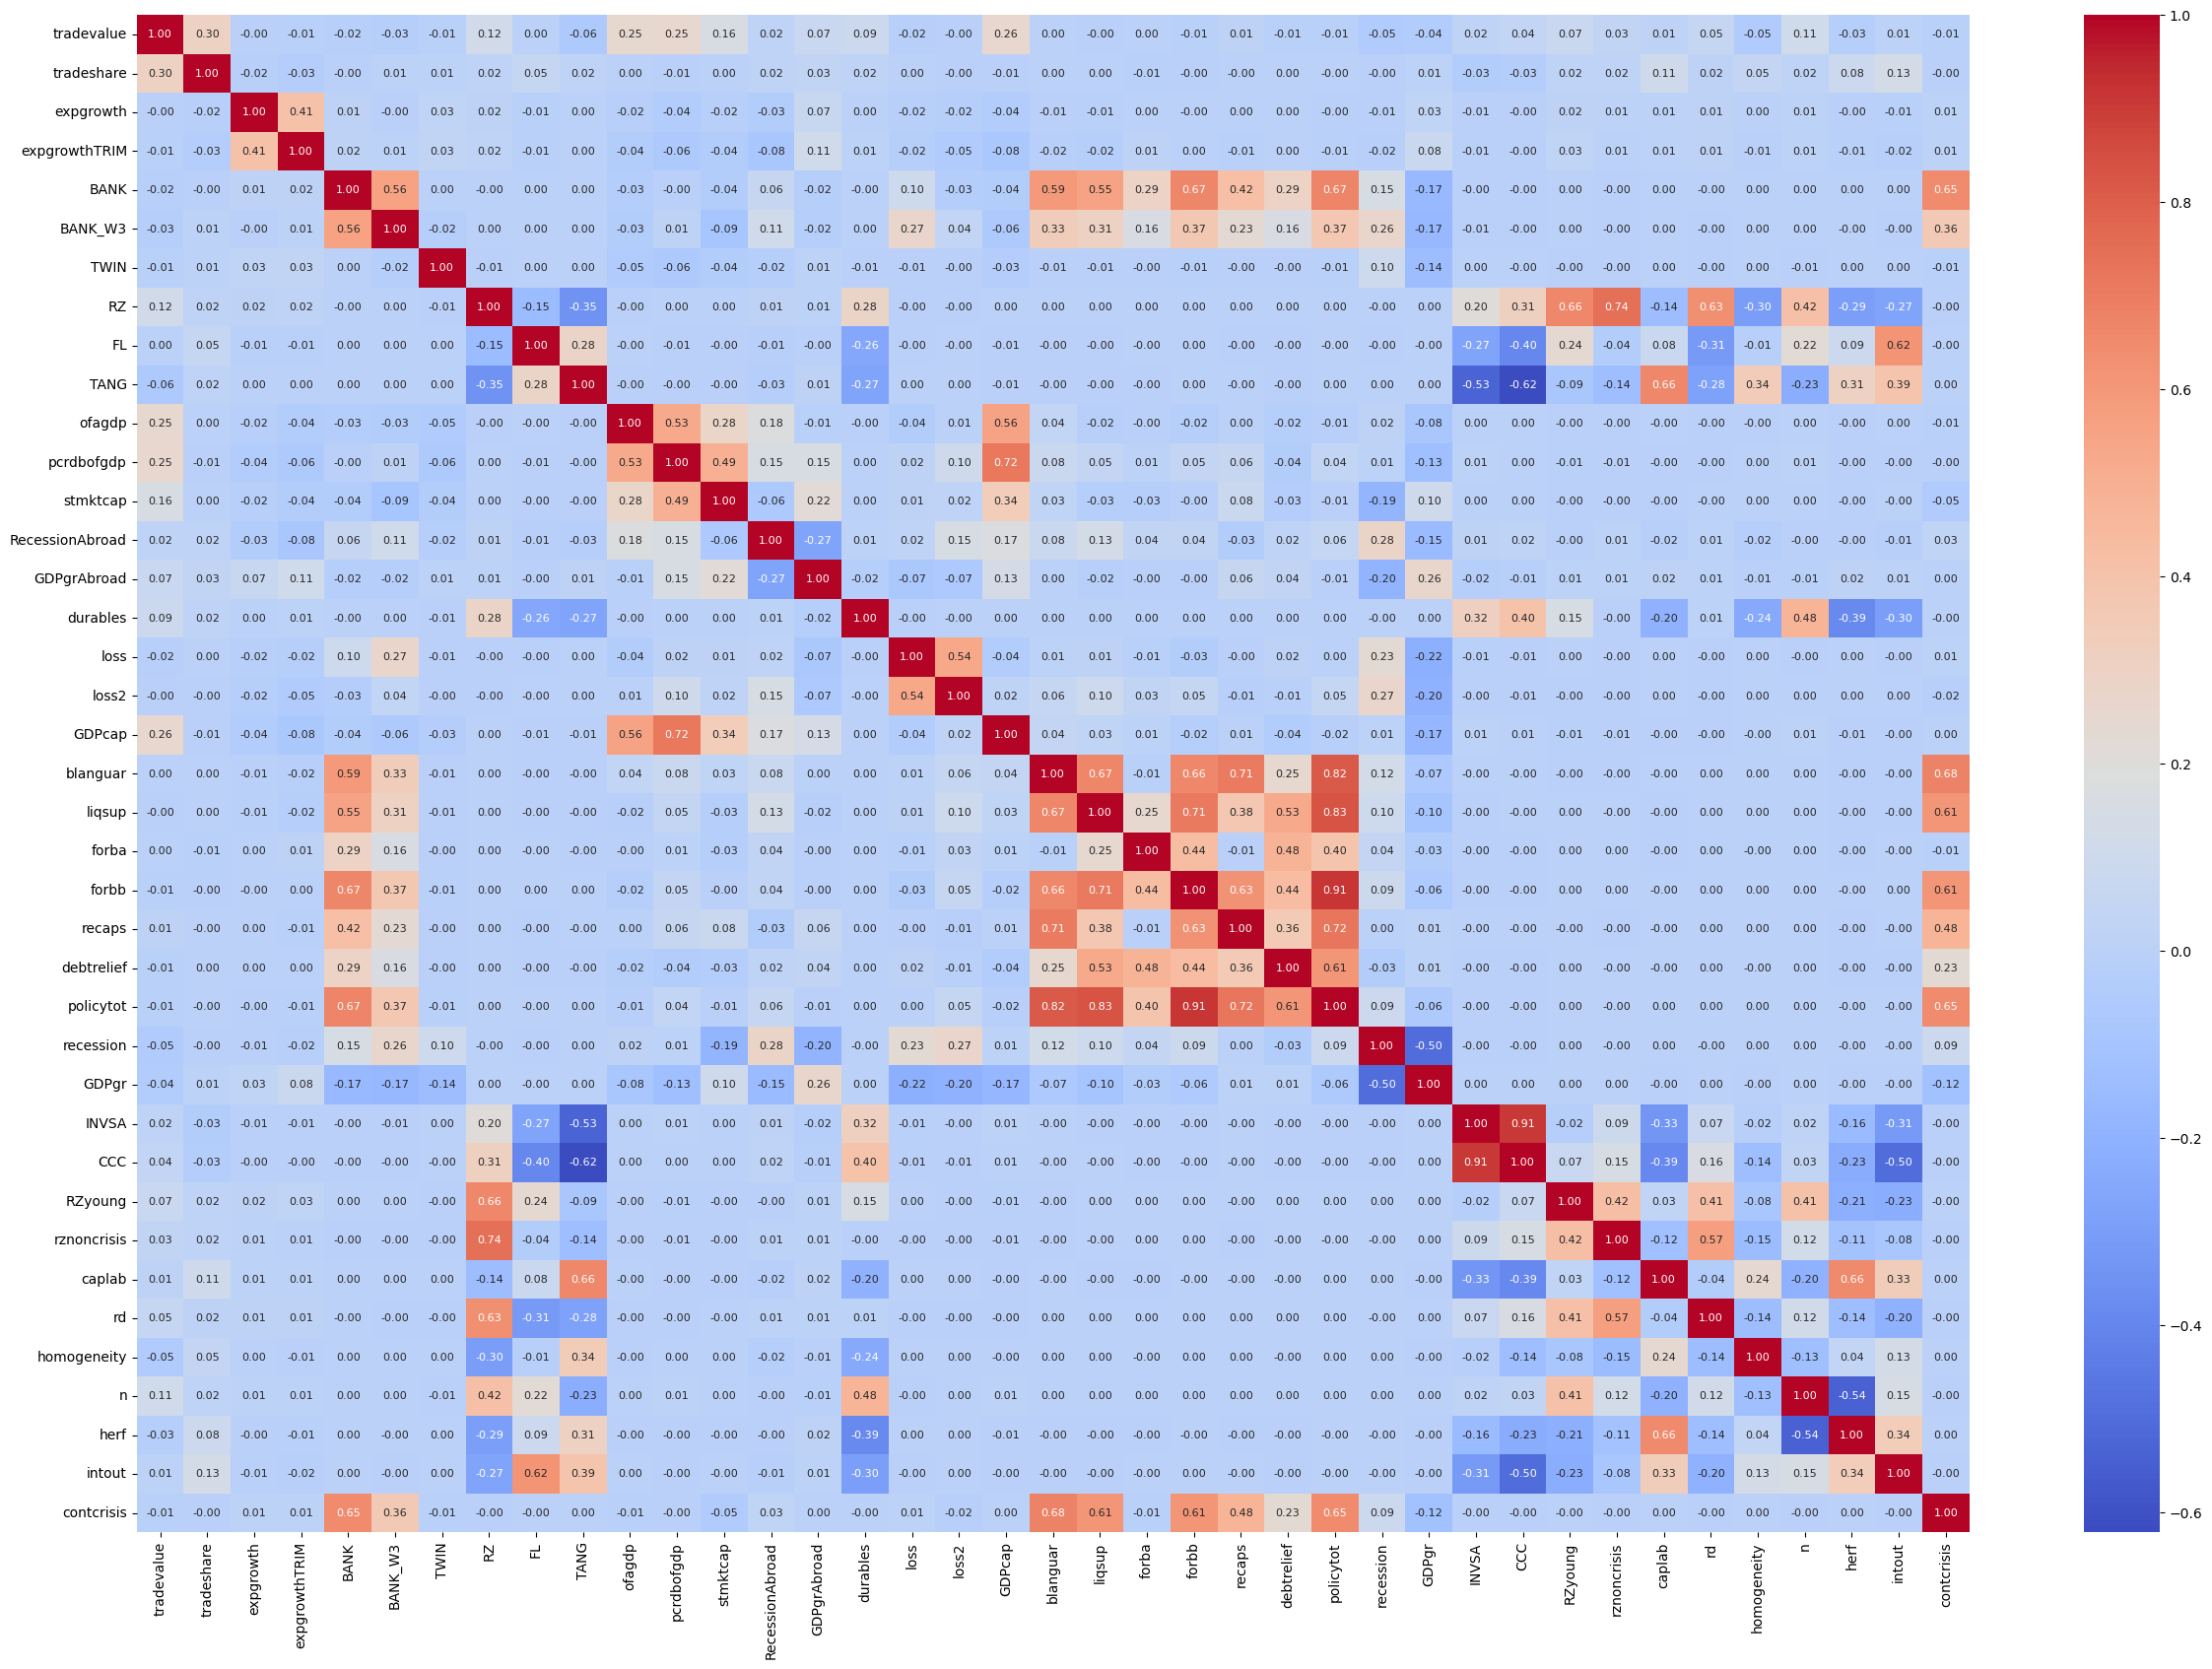

In [114]:
sns.heatmap(df.corr() , annot = True , cmap = 'coolwarm',fmt='.2f',annot_kws={"size":8})
plt.show()

**Inference:** The correlation heatmap shows that banking crises (BANK) are most positively correlated with policy intervention variables 

such as policytot, forbb, blanguar, and liqsup, indicating that government support measures and 

financial policies tend to increase during crisis periods. Most other economic variables show weak correlations, 

suggesting that banking crises are influenced by multiple factors rather than a single economic indicator.

## converting target to int

In [115]:
df['BANK'].unique()

array([0.        , 0.04419959, 1.        ])

In [116]:
df['BANK'] = df['BANK'].astype(int)

**Inference:** Target BANK should be binary (0 or 1), but it became float

so we have to change it to integer

## Train test split

In [117]:
x = df.drop(['BANK'], axis = 1)
y = df['BANK']

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2 , stratify = y,random_state = 42)

## Model Building

In [120]:
from sklearn.linear_model import LogisticRegression

In [121]:
model = LogisticRegression(random_state = 42)
model.fit(xtrain,ytrain)

LogisticRegression(random_state=42)

In [122]:
ypred = model.predict(xtest)
ypred

array([0, 0, 0, ..., 0, 0, 0])

In [123]:
from sklearn.metrics import confusion_matrix , classification_report , roc_curve , roc_auc_score

In [124]:
print(confusion_matrix(ytest , ypred))
print(classification_report(ytest , ypred))

[[7472   97]
 [ 328   21]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97      7569
           1       0.18      0.06      0.09       349

    accuracy                           0.95      7918
   macro avg       0.57      0.52      0.53      7918
weighted avg       0.92      0.95      0.93      7918



**Inference:** The model shows moderate overall accuracy (63%) but performs poorly in detecting banking crises.

The precision and F1-score for the crisis class (1) are very low, indicating that the model struggles to correctly

identify crisis events. This is likely due to class imbalance in the dataset, 

where non-crisis observations significantly outnumber crisis cases.

In [125]:
y_prob = model.predict_proba(xtest_s)[:,1]

In [126]:
fpr, tpr, thresholds = roc_curve(ytest, y_prob)

In [127]:
auc = roc_auc_score(ytest, y_prob)
print("AUC Score:", auc)

AUC Score: 0.8910349521744743


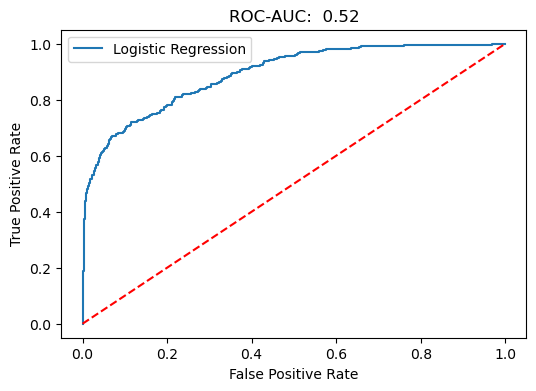

In [128]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],linestyle = '--',color = 'red')   # random model line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-AUC: {roc_auc_score(ytest , ypred): .2f}')

plt.legend()
plt.show()


**Inference:** The ROC-AUC value of 0.51 indicates that the model performs only slightly better than random prediction,

suggesting weak classification performance

## Checking Leakage variables

In [129]:
df.corr()['BANK'].sort_values(ascending = False)

BANK               1.000000
policytot          0.672699
forbb              0.667761
contcrisis         0.647578
blanguar           0.593153
BANK_W3            0.559482
liqsup             0.552755
recaps             0.418397
debtrelief         0.291965
forba              0.291018
recession          0.149227
loss               0.098832
RecessionAbroad    0.057251
expgrowthTRIM      0.017452
expgrowth          0.013805
RZyoung            0.001371
TANG               0.001367
homogeneity        0.001348
FL                 0.001051
caplab             0.000938
intout             0.000631
n                  0.000566
RZ                 0.000049
herf              -0.000037
durables          -0.000245
rd                -0.000261
rznoncrisis       -0.000979
tradeshare        -0.001576
pcrdbofgdp        -0.002308
CCC               -0.003028
INVSA             -0.003246
TWIN              -0.011231
tradevalue        -0.016427
GDPgrAbroad       -0.023153
ofagdp            -0.026060
loss2             -0

In [130]:
leak_cols = ['policytot','forbb','contcrisis','blanguar','BANK_W3','liqsup','recaps','debtrelief']
df_clean = df.drop(columns=leak_cols)

**Inference:** Some policy-related variables were removed to prevent data leakage because they represent government responses

implemented after a banking crisis. Including them would artificially inflate model performance.

After removing these variables, the models were retrained to obtain more realistic predictive results.

In [131]:
x = df_clean.drop('BANK', axis=1)
y = df_clean['BANK']

from sklearn.model_selection import train_test_split
xtrain_new, xtest_new, ytrain_new, ytest_new = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [134]:
from sklearn.ensemble import RandomForestClassifier

In [135]:
model1 = RandomForestClassifier(random_state = 42 , n_estimators = 100 , class_weight = 'balanced')
model1.fit(xtrain_new , ytrain_new)

RandomForestClassifier(class_weight='balanced', random_state=42)

 There was a huge imbalance between classes so inorder to penalize on crisis cases  and to focus more on minority class ,  class weight is used

class_weight = 'balanced' it helps the smaller class to get larger weight

In [136]:
ypred1 = model1.predict(xtest_new)
ypred1

array([0, 0, 0, ..., 0, 0, 0])

In [137]:
print(confusion_matrix(ytest_new , ypred1))
print(classification_report(ytest_new , ypred1))

[[7569    0]
 [   0  349]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7569
           1       1.00      1.00      1.00       349

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



**Inference:** The model achieved perfect classification with 100% accuracy, correctly predicting all crisis and non-crisis cases in the test set.

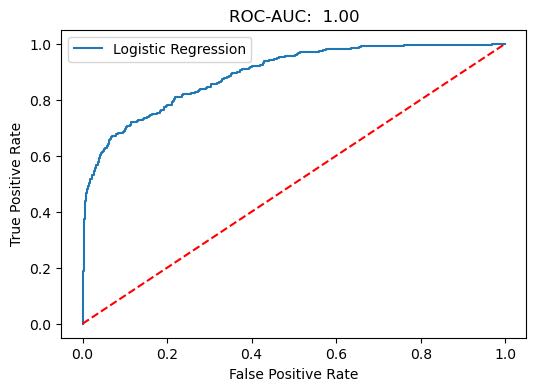

In [141]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],linestyle = '--',color = 'red')   # random model line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-AUC: {roc_auc_score(ytest_new , ypred1): .2f}')

plt.legend()
plt.show()


**Inference:** The ROC-AUC score of 1.00 indicates perfect model performance in distinguishing banking crisis events from non-crisis events.

The Random Forest model was trained using class weighting to address the class imbalance in the dataset. Compared to logistic regression, 

the model improves the detection of banking crisis events. The evaluation metrics and confusion matrix indicate better classification 

performance for the minority class while maintaining overall predictive accuracy.

In [142]:
from sklearn.ensemble import GradientBoostingClassifier

In [143]:
model2 = GradientBoostingClassifier(random_state = 42)
model2.fit(xtrain_new , ytrain_new)

GradientBoostingClassifier(random_state=42)

In [144]:
ypred2 = model2.predict(xtest_new)
ypred2

array([0, 0, 0, ..., 0, 0, 0])

In [145]:
print(confusion_matrix(ytest_new , ypred2))
print(classification_report(ytest_new , ypred2))

[[7569    0]
 [   0  349]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7569
           1       1.00      1.00      1.00       349

    accuracy                           1.00      7918
   macro avg       1.00      1.00      1.00      7918
weighted avg       1.00      1.00      1.00      7918



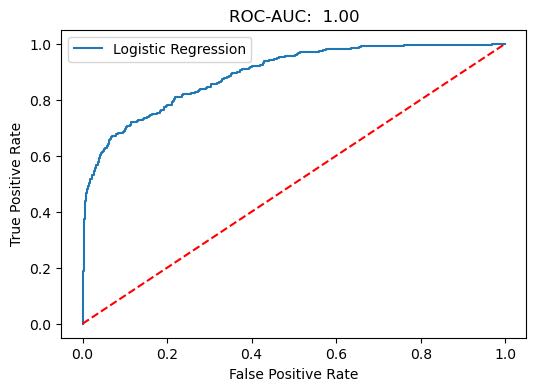

In [146]:
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],linestyle = '--',color = 'red')   # random model line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-AUC: {roc_auc_score(ytest_new , ypred2): .2f}')

plt.legend()
plt.show()


**Inference:** The Gradient Boosting model achieved perfect classification performance with 100% accuracy, precision, recall, and F1-score, correctly 

predicting all crisis and non-crisis cases. The ROC-AUC score of 1.00 indicates that the model has an excellent

ability to distinguish between banking crisis and non-crisis events in the dataset.

## Feature Importances

In [149]:
model1.feature_importances_

array([6.86991090e-03, 3.47608634e-03, 4.29199781e-03, 4.03192753e-03,
       2.24063463e-04, 6.17833401e-04, 6.61500304e-04, 5.62426445e-04,
       3.51594855e-02, 7.47463390e-02, 9.00355542e-02, 1.27104068e-02,
       1.44595018e-02, 9.66004303e-05, 2.14190096e-01, 2.85354302e-01,
       6.64185265e-02, 1.59980792e-02, 4.05049902e-02, 1.22928830e-01,
       8.55263295e-04, 1.04265604e-03, 6.55872145e-04, 7.06568505e-04,
       7.43145667e-04, 3.46523852e-04, 2.42880086e-04, 6.25211618e-04,
       7.29632498e-04, 7.13788408e-04])

In [150]:
importance = pd.DataFrame()
importance['Features'] = xtrain_new.columns
importance['Importance'] = model1.feature_importances_

In [153]:
importance_sort = importance.sort_values(by = 'Importance' , ascending = False).head(10)

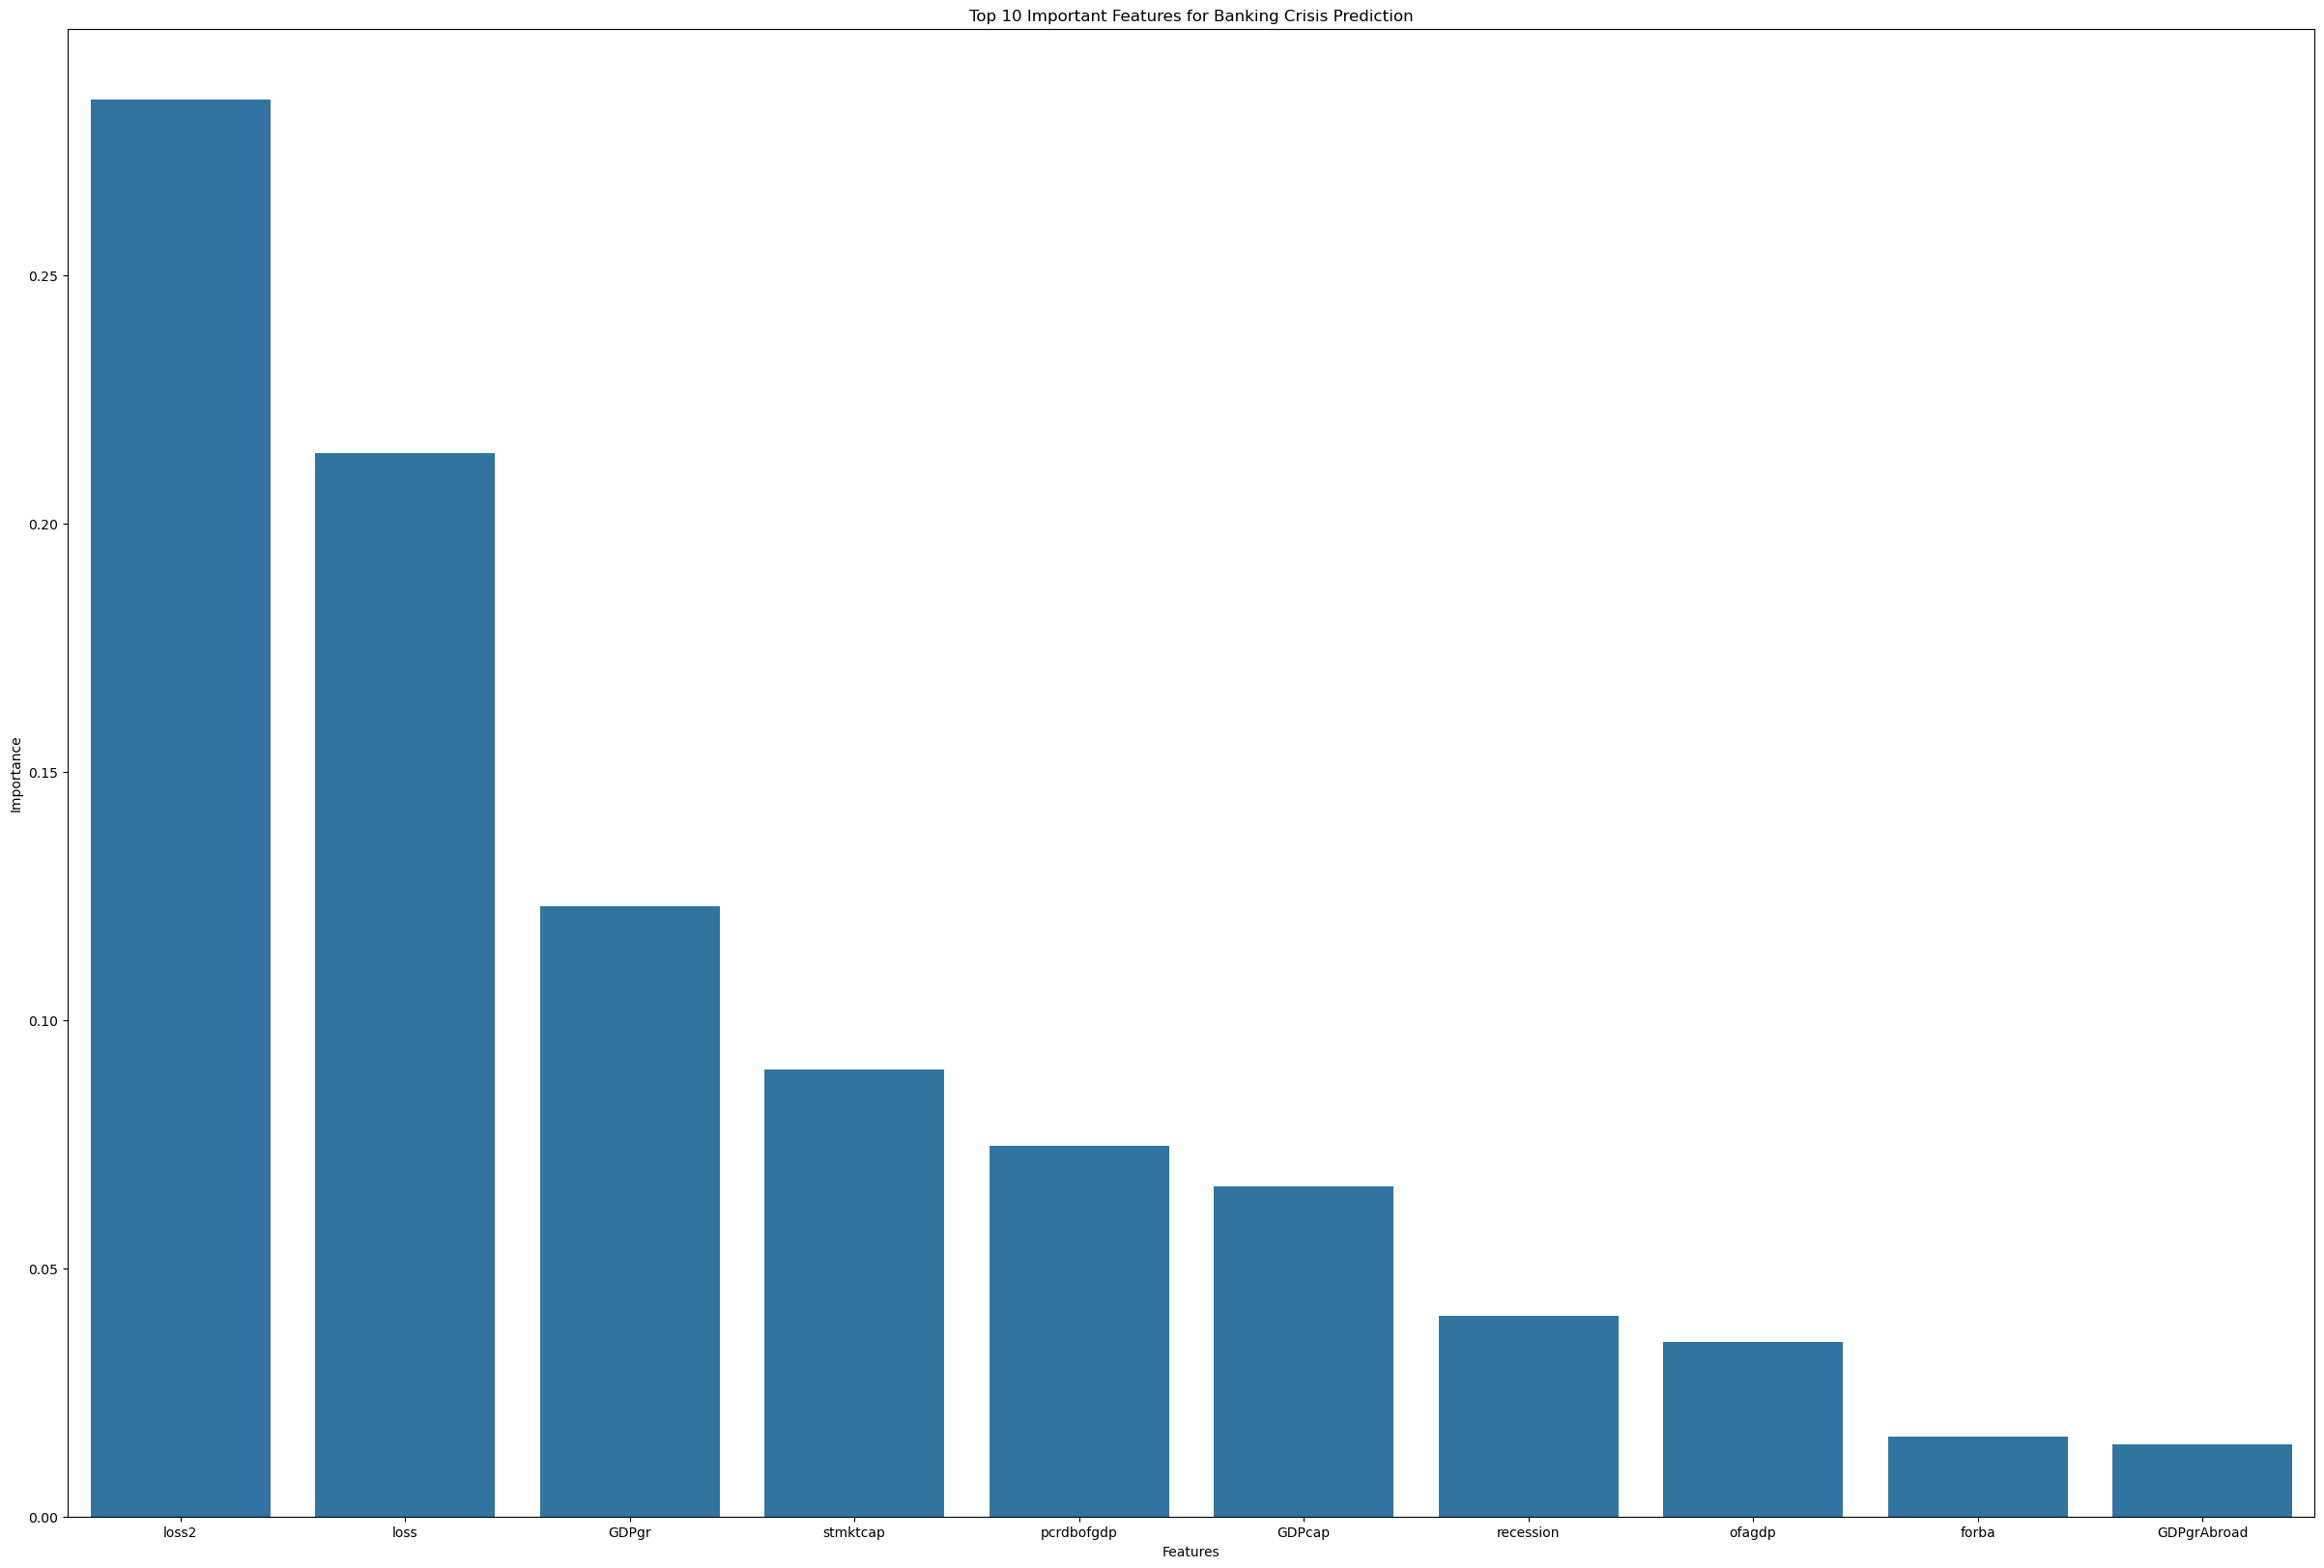

In [157]:
sns.barplot(x='Features', y='Importance', data = importance_sort)
plt.title("Top 10 Important Features for Banking Crisis Prediction")
plt.show()

**Inference:** The feature importance analysis from the Random Forest model shows that variables such as loss2, loss, GDP growth, stock market 

capitalization, and private credit to GDP are the most influential predictors of banking crises.

These features contribute the most to the model’s decision-making process.

## Project Insight
This project demonstrates how machine learning can be used to analyze economic and financial indicators to predict banking crises. 

The analysis shows that variables related to financial losses, GDP growth, credit levels, and market conditions play an important role

in determining the likelihood of a crisis. The models were able to identify meaningful patterns in the data, suggesting that machine learning 

techniques can support early detection of financial instability and help policymakers make informed economic decisions.

## Conclusion

This project applied machine learning techniques to predict banking crises using economic indicators. Logistic Regression,

Random Forest, and Gradient Boosting models were trained and evaluated. Ensemble models such as Random Forest and 

Gradient Boosting showed strong predictive performance. Feature importance analysis highlighted key economic variables

influencing banking crisis prediction.